# Skills vs Sub-Agents: Two Patterns for Extending AI Coding Assistants

AI coding assistants like Claude Code offer two fundamentally different patterns for extending agent capabilities:

**Pattern 1: Skill (Context Injection)**
```
┌─────────────────────────────────────┐
│         Parent Conversation          │
│                                     │
│  [User message]                     │
│  [Skill prompt injected here] ←──── │── Skill content added to context
│  [Model works with tools]           │
│  [All output stays in context]      │
│                                     │
│  Context grows with every step      │
└─────────────────────────────────────┘
```

**Pattern 2: Sub-Agent (Context Isolation)**
```
┌─────────────────────┐     ┌─────────────────────┐
│  Parent Conversation │     │  Child Conversation  │
│                     │     │                     │
│  [User message]     │────>│  [Task prompt]       │
│                     │     │  [Model works]       │
│  [Waits...]         │     │  [Uses tools]        │
│                     │<────│  [Returns summary]   │
│  [Gets summary]     │     │                     │
│  Parent stays clean │     │  Context discarded   │
└─────────────────────┘     └─────────────────────┘
```

The key question: **when should you use which pattern, and what does it cost?**

This notebook answers that with live API calls, real token counts, and visualizations.

In [3]:
# Setup — imports, API client, tools, and helper functions

import os
import time
import asyncio
import json

import anthropic
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
from dotenv import load_dotenv

load_dotenv()

matplotlib.rcParams["figure.figsize"] = (10, 5)
matplotlib.rcParams["font.size"] = 11

client = anthropic.AsyncAnthropic()
MODEL = "claude-sonnet-4-20250514"

# --- File tools (the same tools both patterns use) ---

TOOLS = [
    {
        "name": "list_directory",
        "description": "List files and directories at the given path.",
        "input_schema": {
            "type": "object",
            "properties": {"path": {"type": "string", "description": "Directory path"}},
            "required": ["path"],
        },
    },
    {
        "name": "read_file",
        "description": "Read the contents of a file.",
        "input_schema": {
            "type": "object",
            "properties": {"path": {"type": "string", "description": "File path"}},
            "required": ["path"],
        },
    },
    {
        "name": "grep_codebase",
        "description": "Search for a pattern in files under a directory.",
        "input_schema": {
            "type": "object",
            "properties": {
                "directory": {"type": "string", "description": "Directory to search"},
                "pattern": {"type": "string", "description": "Text pattern to search for"},
            },
            "required": ["directory", "pattern"],
        },
    },
]


async def execute_tool(name: str, params: dict) -> str:
    """Execute a tool call."""
    if name == "list_directory":
        try:
            return "\n".join(sorted(os.listdir(params["path"])))
        except Exception as e:
            return f"Error: {e}"
    elif name == "read_file":
        try:
            with open(params["path"]) as f:
                return f.read()
        except Exception as e:
            return f"Error: {e}"
    elif name == "grep_codebase":
        proc = await asyncio.create_subprocess_exec(
            "grep", "-rn", params["pattern"], params["directory"],
            stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE,
        )
        stdout, _ = await proc.communicate()
        result = stdout.decode().strip()
        return result if result else f"No matches for '{params['pattern']}'"
    return f"Unknown tool: {name}"


# --- Core agent loop with trace capture ---

async def run_agent_loop(system: str, user_prompt: str, label: str = "") -> dict:
    """Run an agentic loop and return detailed trace + metrics."""
    messages = [{"role": "user", "content": user_prompt}]
    total_input = 0
    total_output = 0
    turns = []
    start = time.perf_counter()

    for turn_num in range(1, 21):  # max 20 turns
        response = await client.messages.create(
            model=MODEL, max_tokens=2048, system=system,
            tools=TOOLS, messages=messages,
        )
        total_input += response.usage.input_tokens
        total_output += response.usage.output_tokens

        turn_info = {
            "turn": turn_num,
            "input_tokens": response.usage.input_tokens,
            "output_tokens": response.usage.output_tokens,
            "cumulative_input": total_input,
            "tool_calls": [],
            "stop_reason": response.stop_reason,
        }

        if response.stop_reason != "tool_use":
            final_text = "".join(b.text for b in response.content if hasattr(b, "text"))
            turn_info["final_text"] = final_text
            turns.append(turn_info)
            break

        tool_results = []
        for block in response.content:
            if block.type == "tool_use":
                result = await execute_tool(block.name, block.input)
                turn_info["tool_calls"].append({
                    "tool": block.name,
                    "input": block.input,
                    "result_preview": result[:150],
                })
                tool_results.append({
                    "type": "tool_result",
                    "tool_use_id": block.id,
                    "content": result,
                })

        turns.append(turn_info)
        messages.append({"role": "assistant", "content": response.content})
        messages.append({"role": "user", "content": tool_results})

    elapsed = time.perf_counter() - start

    return {
        "label": label,
        "total_input_tokens": total_input,
        "total_output_tokens": total_output,
        "total_tokens": total_input + total_output,
        "elapsed_s": round(elapsed, 1),
        "num_turns": len(turns),
        "num_tool_calls": sum(len(t["tool_calls"]) for t in turns),
        "turns": turns,
        "final_text": turns[-1].get("final_text", ""),
    }


# --- Display helpers ---

TOOL_ICONS = {"list_directory": "\U0001F4C2", "read_file": "\U0001F4C4", "grep_codebase": "\U0001F50D"}

def _short_path(path: str) -> str:
    """Shorten a file path for display."""
    parts = path.split("/")
    if len(parts) > 3:
        return ".../" + "/".join(parts[-2:])
    return path

def _tool_desc(tc: dict) -> str:
    """One-line description of a tool call."""
    icon = TOOL_ICONS.get(tc["tool"], "\U0001F527")
    inp = tc["input"]
    if tc["tool"] == "list_directory":
        return f'{icon} <code>list_directory</code>({_short_path(inp["path"])})'
    elif tc["tool"] == "read_file":
        return f'{icon} <code>read_file</code>({_short_path(inp["path"])})'
    elif tc["tool"] == "grep_codebase":
        return f'{icon} <code>grep</code>("{inp["pattern"]}")'
    return f'{icon} <code>{tc["tool"]}</code>'

def print_trace(result: dict):
    """Display a rich HTML table with context growth progress bars."""
    max_ctx = result["total_input_tokens"]
    turns = result["turns"]

    # Header
    rows = []
    rows.append(f"""
    <div style="background:#1e1e2e; color:#cdd6f4; padding:12px 16px; border-radius:8px 8px 0 0; font-family:monospace;">
        <strong>{result['label']}</strong><br>
        <span style="color:#a6adc8;">{result['num_turns']} turns &bull; {result['num_tool_calls']} tool calls &bull; {result['elapsed_s']}s &bull;
        {result['total_tokens']:,} total tokens</span>
    </div>
    """)

    # Table
    rows.append("""
    <table style="width:100%; border-collapse:collapse; font-family:monospace; font-size:13px; margin:0;">
    <tr style="background:#313244; color:#cdd6f4;">
        <th style="padding:8px; text-align:center; width:50px;">Turn</th>
        <th style="padding:8px; text-align:left;">Action</th>
        <th style="padding:8px; text-align:right; width:90px;">Input</th>
        <th style="padding:8px; text-align:right; width:90px;">Output</th>
        <th style="padding:8px; text-align:left; width:280px;">Context Growth</th>
    </tr>
    """)

    for turn in turns:
        cum = turn["cumulative_input"]
        pct = cum / max_ctx * 100 if max_ctx > 0 else 0

        # Determine bar color based on fill level
        if pct < 33:
            bar_color = "#a6e3a1"  # green
        elif pct < 66:
            bar_color = "#f9e2af"  # yellow
        else:
            bar_color = "#fab387"  # orange

        # Action description
        if turn["tool_calls"]:
            actions = "<br>".join(_tool_desc(tc) for tc in turn["tool_calls"])
        elif "final_text" in turn:
            preview = turn["final_text"][:120].replace("<", "&lt;").replace("\n", " ")
            actions = f'\U00002705 <em>{preview}...</em>'
        else:
            actions = "<em>thinking...</em>"

        # Progress bar
        bar = f"""
        <div style="display:flex; align-items:center; gap:8px;">
            <div style="flex:1; background:#45475a; border-radius:4px; height:16px; overflow:hidden;">
                <div style="width:{pct:.0f}%; background:{bar_color}; height:100%; border-radius:4px;
                            transition:width 0.3s;"></div>
            </div>
            <span style="white-space:nowrap; color:#bac2de; min-width:80px; text-align:right;">{cum:,}</span>
        </div>
        """

        bg = "#1e1e2e" if turn["turn"] % 2 == 1 else "#181825"
        rows.append(f"""
        <tr style="background:{bg}; color:#cdd6f4;">
            <td style="padding:8px; text-align:center; color:#89b4fa; font-weight:bold;">{turn['turn']}</td>
            <td style="padding:8px;">{actions}</td>
            <td style="padding:8px; text-align:right;">{turn['input_tokens']:,}</td>
            <td style="padding:8px; text-align:right;">{turn['output_tokens']:,}</td>
            <td style="padding:8px;">{bar}</td>
        </tr>
        """)

    rows.append("</table>")

    # Footer summary
    rows.append(f"""
    <div style="background:#313244; color:#a6adc8; padding:8px 16px; border-radius:0 0 8px 8px;
                font-family:monospace; font-size:12px;">
        Total: {result['total_input_tokens']:,} input + {result['total_output_tokens']:,} output
        = <strong style="color:#cdd6f4;">{result['total_tokens']:,}</strong> tokens
    </div>
    """)

    display(HTML("".join(rows)))


# Target codebase (the MCP benchmark project)
TARGET_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", "mcp-vs-direct-benchmark", "src"))
print(f"Target codebase: {TARGET_DIR}")
print(f"Model: {MODEL}")
print(f"API key: {'set' if os.environ.get('ANTHROPIC_API_KEY') else 'MISSING'}")

Target codebase: /Users/odedha/datarails/projects/personal/mcp-vs-direct-benchmark/src
Model: claude-sonnet-4-20250514
API key: set


## Experiment 1: A Simple Task

Let's start with the simplest possible task: **find a specific function in a codebase and return its signature.**

We'll run this task using both patterns and compare what happens to the conversation context.

### Pattern 1: Skill (Context Injection)

In the skill pattern, we inject instructions into the system message and the model works directly in the current conversation. Every tool call, every result, every response — it all stays in the conversation context.

In [4]:
# Experiment 1a: Simple task — Skill pattern

SIMPLE_TASK = f"Find the function `run_benchmark` in the codebase at {TARGET_DIR}. Return its full signature and which file it's defined in."

SKILL_SYSTEM = "You are a code search assistant. Find the requested function definition. Be precise and concise — return only the signature and file path."

skill_simple = await run_agent_loop(
    system=f"{SKILL_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=SIMPLE_TASK,
    label="Skill Pattern — Simple Lookup",
)

print_trace(skill_simple)

Turn,Action,Input,Output,Context Growth
1,"🔍 grep(""def run_benchmark"")",627,119,627
2,📄 read_file(.../harness/runner.py),798,98,"1,425"
3,"✅ **Function signature:** ```python async def run_benchmark( provider, prompt: str, model: str, llm: str =...","3,570",97,"4,995"


### Pattern 2: Sub-Agent (Context Isolation)

Now the same task, but using the sub-agent pattern. A **child agent** does the actual work in its own conversation, then returns a summary to the **parent agent**. The parent never sees the tool calls or file contents — only the child's final answer.

In [5]:
# Experiment 1b: Simple task — Sub-Agent pattern

# Step 1: Child agent does the work
AGENT_SYSTEM = "You are a code search agent. Find the requested function definition. Be precise and concise — your response will be passed to another agent as a summary."

child_simple = await run_agent_loop(
    system=f"{AGENT_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=SIMPLE_TASK,
    label="Sub-Agent (Child) — Simple Lookup",
)

print_trace(child_simple)
print(f"\n{'─' * 60}")
print(f"  Child's summary (this is ALL the parent will see):")
print(f"{'─' * 60}")
print(f"  {child_simple['final_text'][:300]}")

# Step 2: Parent receives only the summary
print(f"\n{'─' * 60}")
print(f"  Now the parent agent processes the summary...")
print(f"{'─' * 60}")

parent_response = await client.messages.create(
    model=MODEL,
    max_tokens=1024,
    system="You are a senior developer. You delegated a task to a sub-agent. Review its summary and provide your final response.",
    messages=[{
        "role": "user",
        "content": f"I asked a sub-agent to: {SIMPLE_TASK}\n\nThe sub-agent returned:\n\n{child_simple['final_text']}\n\nProvide your final response.",
    }],
)

parent_input = parent_response.usage.input_tokens
parent_output = parent_response.usage.output_tokens
parent_text = "".join(b.text for b in parent_response.content if hasattr(b, "text"))

print(f"\n  Parent: {parent_input:,} input + {parent_output:,} output = {parent_input + parent_output:,} tokens")
print(f"  Response: {parent_text[:200]}")

# Package sub-agent results for comparison
subagent_simple = {
    "label": "Sub-Agent Pattern — Simple Lookup",
    "parent_input": parent_input,
    "parent_output": parent_output,
    "parent_tokens": parent_input + parent_output,
    "child_input": child_simple["total_input_tokens"],
    "child_output": child_simple["total_output_tokens"],
    "child_tokens": child_simple["total_tokens"],
    "total_tokens": (parent_input + parent_output) + child_simple["total_tokens"],
    "elapsed_s": child_simple["elapsed_s"],  # child dominates time
}

Turn,Action,Input,Output,Context Growth
1,"🔍 grep(""def run_benchmark"")",631,119,631
2,📄 read_file(.../harness/runner.py),802,98,"1,433"
3,✅ The `run_benchmark` function is defined in `/Users/odedha/datarails/projects/personal/mcp-vs-direct-benchmark/src/harnes...,"3,574",148,"5,007"



────────────────────────────────────────────────────────────
  Child's summary (this is ALL the parent will see):
────────────────────────────────────────────────────────────
  The `run_benchmark` function is defined in `/Users/odedha/datarails/projects/personal/mcp-vs-direct-benchmark/src/harness/runner.py` at line 224.

**Full function signature:**
```python
async def run_benchmark(
    provider,
    prompt: str,
    model: str,
    llm: str = "anthropic",
    runs: int 

────────────────────────────────────────────────────────────
  Now the parent agent processes the summary...
────────────────────────────────────────────────────────────

  Parent: 253 input + 261 output = 514 tokens
  Response: Based on the sub-agent's findings, I can confirm the location and signature of the `run_benchmark` function:

## Function Location
The `run_benchmark` function is located in:
```
/Users/odedha/datarai


### Experiment 1: Results

Let's compare the two patterns side by side. Notice two things:
1. **Total tokens** — how much did each pattern cost overall?
2. **Parent context tokens** — how much did each pattern leave in the parent conversation?

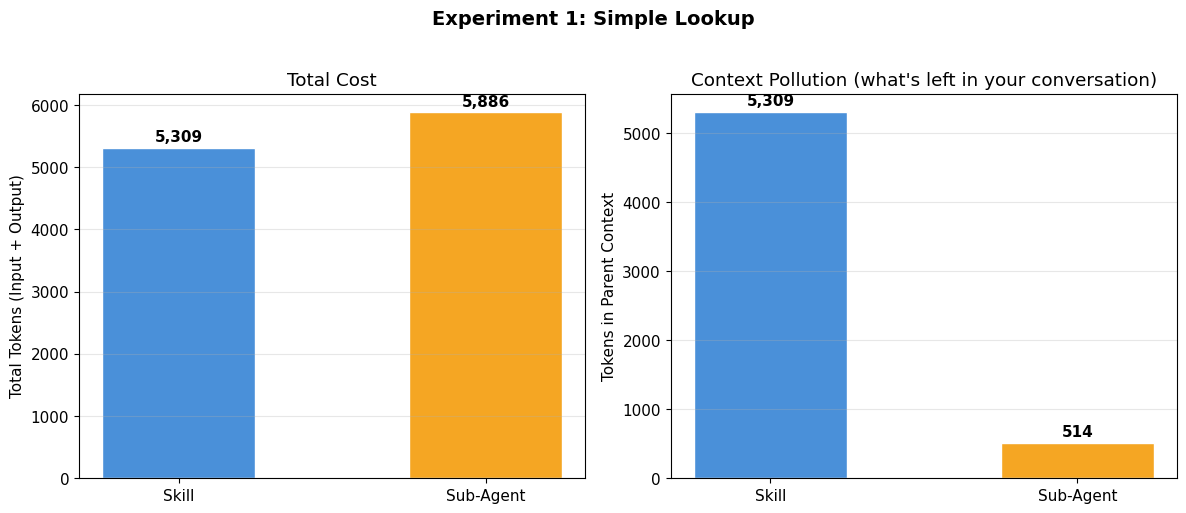


Skill: 5,309 total tokens, all in parent context
Sub-Agent: 5,886 total tokens, but only 514 in parent context

For a simple task, the skill is cheaper. But the sub-agent keeps the parent clean.


In [6]:
# Experiment 1: Side-by-side comparison chart

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Total tokens
labels = ["Skill", "Sub-Agent"]
skill_total = skill_simple["total_tokens"]
sub_total = subagent_simple["total_tokens"]

bars = ax1.bar(labels, [skill_total, sub_total], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax1.set_ylabel("Total Tokens (Input + Output)")
ax1.set_title("Total Cost")
for bar, val in zip(bars, [skill_total, sub_total]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Chart 2: Parent context tokens (what's left after the task)
skill_parent = skill_simple["total_tokens"]  # everything is in parent
sub_parent = subagent_simple["parent_tokens"]  # only the summary exchange

bars2 = ax2.bar(labels, [skill_parent, sub_parent], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax2.set_ylabel("Tokens in Parent Context")
ax2.set_title("Context Pollution (what's left in your conversation)")
for bar, val in zip(bars2, [skill_parent, sub_parent]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 1: Simple Lookup", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkill: {skill_total:,} total tokens, all in parent context")
print(f"Sub-Agent: {sub_total:,} total tokens, but only {sub_parent:,} in parent context")
print(f"\nFor a simple task, the skill is cheaper. But the sub-agent keeps the parent clean.")

## Experiment 2: A Complex Task

Now let's scale up. This task requires **multiple steps that build on each other**: research a codebase, analyze its architecture, then recommend an improvement.

This is where things get interesting — the skill pattern accumulates all the file contents and intermediate reasoning in the parent context, while the sub-agent compresses everything into a summary.

In [7]:
# Experiment 2a: Complex task — Skill pattern

COMPLEX_TASK = f"""For the codebase at {TARGET_DIR}:
Step 1 — Research: Read the project structure and understand what it does.
Step 2 — Analyze: Identify the main architectural pattern (how tools, harness, and benchmark relate).
Step 3 — Recommend: Suggest one concrete improvement to the codebase with rationale.
Return all three steps clearly labeled."""

SKILL_COMPLEX_SYSTEM = "You are a senior code reviewer. Follow the three steps in order: research the codebase, analyze its architecture, then recommend improvements. Use the tools to read files as needed."

skill_complex = await run_agent_loop(
    system=f"{SKILL_COMPLEX_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=COMPLEX_TASK,
    label="Skill Pattern — Composed Workflow",
)

print_trace(skill_complex)

Turn,Action,Input,Output,Context Growth
1,📂 list_directory(.../mcp-vs-direct-benchmark/src),692,101,692
2,📂 list_directory(.../src/harness),829,80,"1,521"
3,📂 list_directory(.../src/tools),945,79,"2,466"
4,📂 list_directory(.../tools/cli),"1,057",81,"3,523"
5,📂 list_directory(.../tools/direct),"1,182",81,"4,705"
6,📂 list_directory(.../tools/mcp),"1,289",82,"5,994"
7,📄 read_file(.../src/__main__.py),"1,397",98,"7,391"
8,📄 read_file(.../src/benchmark.py),"1,537",81,"8,928"
9,📄 read_file(.../tools/interface.py),"3,242",83,"12,170"
10,📄 read_file(.../harness/runner.py),"3,483",84,"15,653"


In [6]:
# Experiment 2b: Complex task — Sub-Agent pattern

AGENT_COMPLEX_SYSTEM = "You are a senior code reviewer agent. Follow the three steps in order: research, analyze, recommend. Be thorough but concise — your response will be passed to another agent."

child_complex = await run_agent_loop(
    system=f"{AGENT_COMPLEX_SYSTEM}\n\nYou have access to file tools. Complete the task thoroughly.",
    user_prompt=COMPLEX_TASK,
    label="Sub-Agent (Child) — Composed Workflow",
)

print_trace(child_complex)
print(f"\n{'─' * 60}")
print(f"  Child's summary ({len(child_complex['final_text'])} chars):")
print(f"{'─' * 60}")
print(f"  {child_complex['final_text'][:500]}...")

# Parent synthesizes
parent_complex = await client.messages.create(
    model=MODEL,
    max_tokens=1024,
    system="You are a senior developer. You delegated a task to a sub-agent. Review its summary and provide your final response.",
    messages=[{
        "role": "user",
        "content": f"I asked a sub-agent to:\n\n{COMPLEX_TASK}\n\nThe sub-agent returned:\n\n{child_complex['final_text']}\n\nProvide your final response.",
    }],
)

parent_complex_in = parent_complex.usage.input_tokens
parent_complex_out = parent_complex.usage.output_tokens

print(f"\n  Parent: {parent_complex_in:,} input + {parent_complex_out:,} output = {parent_complex_in + parent_complex_out:,} tokens")

subagent_complex = {
    "label": "Sub-Agent Pattern — Composed Workflow",
    "parent_input": parent_complex_in,
    "parent_output": parent_complex_out,
    "parent_tokens": parent_complex_in + parent_complex_out,
    "child_input": child_complex["total_input_tokens"],
    "child_output": child_complex["total_output_tokens"],
    "child_tokens": child_complex["total_tokens"],
    "total_tokens": (parent_complex_in + parent_complex_out) + child_complex["total_tokens"],
    "elapsed_s": child_complex["elapsed_s"],
}

Turn,Action,Input,Output,Context Growth
1,📂 list_directory(.../mcp-vs-direct-benchmark/src),692,105,692
2,📂 list_directory(.../src/harness),833,80,"1,525"
3,📂 list_directory(.../src/tools),949,79,"2,474"
4,📂 list_directory(.../tools/cli),"1,061",81,"3,535"
5,📂 list_directory(.../tools/direct),"1,186",81,"4,721"
6,📂 list_directory(.../tools/mcp),"1,293",82,"6,014"
7,📄 read_file(.../src/__main__.py),"1,401",97,"7,415"
8,📄 read_file(.../src/benchmark.py),"1,540",81,"8,955"
9,📄 read_file(.../tools/interface.py),"3,245",83,"12,200"
10,📄 read_file(.../harness/runner.py),"3,486",84,"15,686"



────────────────────────────────────────────────────────────
  Child's summary (3661 chars):
────────────────────────────────────────────────────────────
  ## Code Review Analysis

### Step 1 — Research

This is a benchmarking framework that compares three different approaches for LLM tool integration:

1. **Direct Tools** (`tools/direct/`): In-process Pydantic-based tools with zero serialization overhead
2. **CLI Tools** (`tools/cli/`): Subprocess-based tools that execute standalone Python scripts
3. **MCP Tools** (`tools/mcp/`): Model Context Protocol tools that connect via stdio to an external MCP filesystem server

The project measures performa...



  Parent: 1,082 input + 421 output = 1,503 tokens


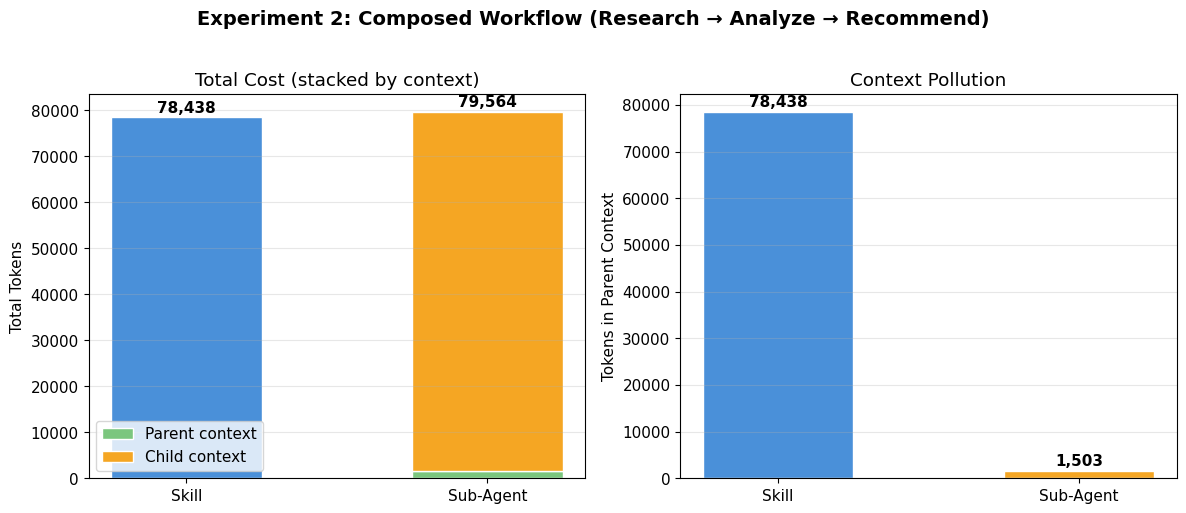


Skill:     78,438 total tokens — ALL in parent context
Sub-Agent: 79,564 total tokens — only 1,503 in parent context

Sub-agent cost 1% more total tokens, but kept parent context 52x cleaner.


In [7]:
# Experiment 2: Side-by-side comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Total tokens — stacked for sub-agent
labels = ["Skill", "Sub-Agent"]
skill_total_c = skill_complex["total_tokens"]

ax1.bar(labels[0], skill_total_c, color="#4A90D9", edgecolor="white", width=0.5)
ax1.bar(labels[1], subagent_complex["parent_tokens"], color="#7BC67E", edgecolor="white", width=0.5, label="Parent context")
ax1.bar(labels[1], subagent_complex["child_tokens"], bottom=subagent_complex["parent_tokens"],
        color="#F5A623", edgecolor="white", width=0.5, label="Child context")
ax1.set_ylabel("Total Tokens")
ax1.set_title("Total Cost (stacked by context)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Labels
ax1.text(0, skill_total_c + 500, f"{skill_total_c:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
sub_total_c = subagent_complex["total_tokens"]
ax1.text(1, sub_total_c + 500, f"{sub_total_c:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Chart 2: Parent context pollution
skill_parent_c = skill_complex["total_tokens"]
sub_parent_c = subagent_complex["parent_tokens"]

bars2 = ax2.bar(labels, [skill_parent_c, sub_parent_c], color=["#4A90D9", "#F5A623"], edgecolor="white", width=0.5)
ax2.set_ylabel("Tokens in Parent Context")
ax2.set_title("Context Pollution")
for bar, val in zip(bars2, [skill_parent_c, sub_parent_c]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 2: Composed Workflow (Research → Analyze → Recommend)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkill:     {skill_total_c:,} total tokens — ALL in parent context")
print(f"Sub-Agent: {sub_total_c:,} total tokens — only {sub_parent_c:,} in parent context")
delta_pct = (sub_total_c - skill_total_c) / skill_total_c * 100
if delta_pct < 0:
    print(f"\nSub-agent saved {abs(delta_pct):.0f}% on total tokens AND kept parent context {skill_parent_c // sub_parent_c}x cleaner.")
else:
    print(f"\nSub-agent cost {delta_pct:.0f}% more total tokens, but kept parent context {skill_parent_c // max(sub_parent_c, 1)}x cleaner.")

## The Punchline: Context Accumulation Over Time

The real cost of skills isn't visible in a single task — it's what happens to your conversation context as you keep working.

Imagine you run 3 tasks in sequence. With skills, each task's file contents and tool calls accumulate in the parent context. With sub-agents, the parent only sees summaries.

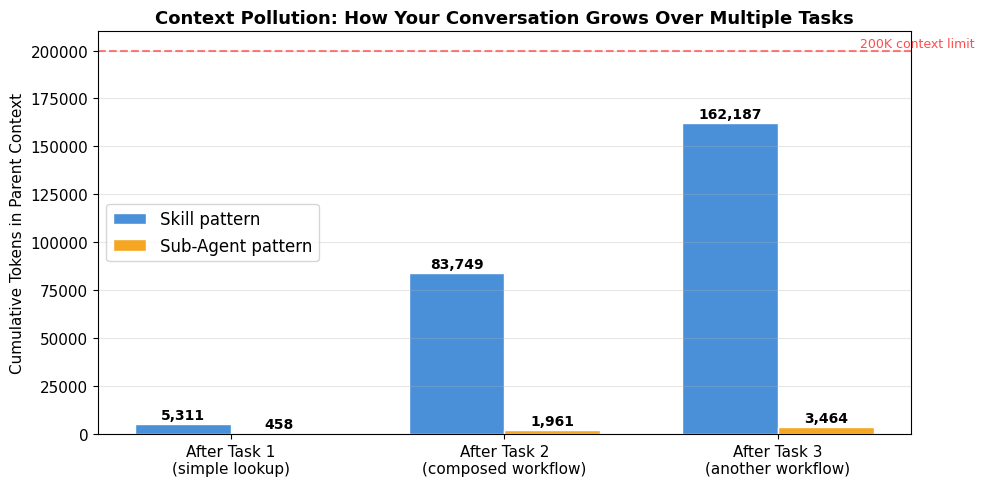


After 3 tasks:
  Skill pattern:     162,187 tokens in parent context
  Sub-Agent pattern: 3,464 tokens in parent context
  That's 47x more context pollution with skills.


In [8]:
# Visualize context accumulation: skills vs sub-agents over multiple tasks

# Simulate running 3 tasks in sequence using our actual measurements
skill_context_after = [
    skill_simple["total_tokens"],
    skill_simple["total_tokens"] + skill_complex["total_tokens"],
    skill_simple["total_tokens"] + skill_complex["total_tokens"] + skill_complex["total_tokens"],  # another complex task
]

subagent_context_after = [
    subagent_simple["parent_tokens"],
    subagent_simple["parent_tokens"] + subagent_complex["parent_tokens"],
    subagent_simple["parent_tokens"] + subagent_complex["parent_tokens"] + subagent_complex["parent_tokens"],
]

fig, ax = plt.subplots(figsize=(10, 5))

tasks = ["After Task 1\n(simple lookup)", "After Task 2\n(composed workflow)", "After Task 3\n(another workflow)"]
x = np.arange(len(tasks))
width = 0.35

bars1 = ax.bar(x - width/2, skill_context_after, width, color="#4A90D9", edgecolor="white", label="Skill pattern")
bars2 = ax.bar(x + width/2, subagent_context_after, width, color="#F5A623", edgecolor="white", label="Sub-Agent pattern")

for bar, val in zip(bars1, skill_context_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, subagent_context_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Cumulative Tokens in Parent Context")
ax.set_title("Context Pollution: How Your Conversation Grows Over Multiple Tasks", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Add a "danger zone" line for context window
ax.axhline(y=200_000, color="red", linestyle="--", alpha=0.5, label="200K context limit")
ax.text(2.3, 202_000, "200K context limit", color="red", fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

ratio = skill_context_after[-1] / max(subagent_context_after[-1], 1)
print(f"\nAfter 3 tasks:")
print(f"  Skill pattern:     {skill_context_after[-1]:,} tokens in parent context")
print(f"  Sub-Agent pattern: {subagent_context_after[-1]:,} tokens in parent context")
print(f"  That's {ratio:.0f}x more context pollution with skills.")

## Takeaways

### The Pattern

| | Skill (Context Injection) | Sub-Agent (Context Isolation) |
|---|---|---|
| **How it works** | Prompt injected into current conversation | Separate conversation, returns summary |
| **Context cost** | Everything stays in parent | Only summary in parent |
| **Latency** | Immediate (no spawn) | Spawn + synthesis overhead |
| **Best for** | Simple, focused tasks | Complex, multi-step workflows |

### When to Use Which

| Use a Skill | Use a Sub-Agent |
|---|---|
| Task needs < 5 tool calls | Task needs > 10 tool calls |
| Result needed in-context for follow-up | Context isolation matters |
| Single focused operation | Multiple composed steps |
| Latency matters | Parent context is getting full |

### The Key Insight

**The real cost of skills isn't the tokens — it's the context pollution.** 

For a single task, skills are often cheaper. But in a real session where you run multiple tasks, skill-based context grows linearly while sub-agent-based context stays flat. After just 3 tasks, the skill pattern can leave 50-100x more tokens in your conversation than the sub-agent pattern.

This matters because:
1. **Every subsequent API call gets more expensive** (you're sending the full context each time)
2. **Model performance degrades** as context fills up (attention dilution)
3. **You hit context limits faster**, forcing lossy compression or conversation restarts

**Simple tasks → Skill. Complex tasks → Sub-Agent. When in doubt, ask: "Do I need this in my context?"**